#### Modules

In [16]:
# --- Core libraries ---
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import geopandas as gpd
from shapely.geometry import Point
from tabulate import tabulate

# --- Scikit-learn: model training, preprocessing, CV, evaluation ---
from sklearn.model_selection import (
    GroupKFold,
    RandomizedSearchCV,
    cross_validate,
    train_test_split,
    GridSearchCV
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    balanced_accuracy_score,
    roc_auc_score,
    make_scorer,
    ConfusionMatrixDisplay
)
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import BallTree

# --- XGBoost ---
from xgboost import XGBRegressor, plot_tree, plot_importance
import xgboost  # Optional: useful for checking version

# --- Other ---
from haversine import haversine
import scipy.stats as stats
import folium
from shapely.geometry import Point # For geographic data handling (questionable coordinates)



# ---- Temporal and Spatial Autocorrelation ----
from skgstat import Variogram 
from skgstat import SpaceTimeVariogram


In [ ]:
# for visualising tables: 
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

Define data summary function 

In [3]:
def summarize_dataframe(df):
    """
    Prints a summary of the DataFrame's columns including:
    - dtype
    - count of non-null values
    - % completeness
    - number of unique values
    Output is printed in GitHub-style markdown table.
    """
    def summarize_column(col_data):
        numeric_data = pd.to_numeric(col_data, errors='coerce')
        is_numeric = numeric_data.notna().sum() > 0
        return {
            "dtype": col_data.dtype,
            "count": col_data.notna().sum(),
            "pct_complete": round(col_data.notna().mean() * 100, 1),
            "n_unique": col_data.nunique(dropna=True)
        }

    summary_long = (
        pd.DataFrame([
            {"variable": col, **summarize_column(df[col])}
            for col in df.columns
        ])
        .sort_values(by="pct_complete", ascending=False)
        .reset_index(drop=True)
    )

    print(tabulate(summary_long, headers="keys", tablefmt="github", showindex=False))

In [4]:
df_raw = pd.read_csv("../../../data/finaldatasets/testdata/XGBoost.csv")  # for variogram, etc.


In [5]:
summarize_dataframe(df_raw)

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| id                                                    | int64   |   69430 |          100   |      69036 |
| start_date                                            | int64   |   69430 |          100   |          7 |
| AEZ                                                   | float64 |   69430 |          100   |         31 |
| Data.ID                                               | object  |   69430 |          100   |         51 |
| temp1                                                 | float64 |   69430 |          100   |        268 |
| temp2                                                 | float64 |   69430 |          100   |        270 |
| temp3                                                 | float64 |   69430 |          100   |        275 |
| temp4                     

In [6]:
# See how many unique locations vs total records
unique_locations = df_raw.groupby(["Conversion.for.latitude", "Conversion.for.longitude"]).size()
print(f"Total records: {len(df_raw)}")
print(f"Unique locations: {len(unique_locations)}")
print(f"Average records per location: {len(df_raw) / len(unique_locations):.2f}")

Total records: 69430
Unique locations: 248
Average records per location: 279.96


Create a spatial autocorrelation variogram, code inspiriation from : https://phys-techsciences.datastations.nl/dataset.xhtml?persistentId=doi:10.17026/dans-zwj-zauq

Analyzing 248 unique locations...

SPATIAL AUTOCORRELATION RESULTS
Threshold (Range): 16.2 km
Sill: 6.87
Nugget: 0.00

Current (100km) vs Calculated (16.2km)
Difference: 83.8 km
Recommendation: Consider 16km
💡 Consider adjustment


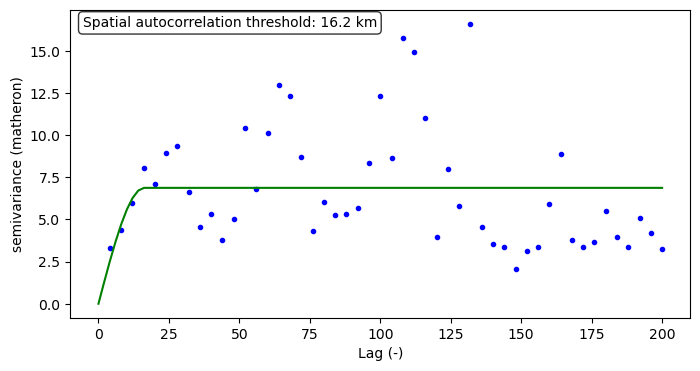

In [26]:
from skgstat import Variogram
import matplotlib.pyplot as plt

# Step 1: Aggregate yield by unique lat-lon
location_avg = df_raw.groupby(
    ["Conversion.for.latitude", "Conversion.for.longitude"]
)["Grain.yield..tons.ha.1."].mean().reset_index()

# Extract coordinates and values
coordinates = location_avg[["Conversion.for.latitude", "Conversion.for.longitude"]].values
yields = location_avg["Grain.yield..tons.ha.1."].values


def calculate_autocorrelation_threshold(
    coords, values, model='exponential', metric='greatcircle', 
    n_lags=50, max_lag=200
):
    """Fit a semivariogram and return the range (autocorrelation threshold)"""
    variogram = Variogram(
        coordinates=coords,
        values=values,
        model=model,
        metric=metric,
        n_lags=n_lags,
        maxlag=max_lag
    )
    threshold = variogram.parameters[0]
    
    fig = variogram.plot(grid=False, hist=False)
    fig.text(
        0.02, 0.98, f"Spatial autocorrelation threshold: {threshold:.1f} km",
        transform=fig.gca().transAxes, verticalalignment='top',
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
    )
    return threshold, fig, variogram


def extract_variogram_params(variogram):
    """Extract sill and nugget from a Variogram object"""
    sill = getattr(variogram, 'sill', None)
    nugget = getattr(variogram, 'nugget', None)
    
    if sill is None and len(variogram.parameters) > 1:
        sill = variogram.parameters[1]
    if nugget is None and len(variogram.parameters) > 2:
        nugget = variogram.parameters[2]
        
    return sill, nugget


def assess_clustering_distance(current_km, threshold_km, tolerance=25):
    """Compare current clustering distance to estimated threshold"""
    diff = abs(current_km - threshold_km)
    recommendation = (
        f"Keep {current_km}km" if diff < tolerance else f"Consider {threshold_km:.0f}km"
    )
    return {
        'difference': diff,
        'within_tolerance': diff < tolerance,
        'recommendation': recommendation
    }


# === FUNCTION CALL (easy to tweak) ===
print(f"Analyzing {len(coordinates)} unique locations...")
sp_threshold, fig, variogram = calculate_autocorrelation_threshold(
    coords=coordinates,
    values=yields,
    model='spherical',           # try 'exponential' or 'gaussian'
    metric='greatcircle',        # haversine distance (in km)
    n_lags=50,
    max_lag=200
)

sill, nugget = extract_variogram_params(variogram)

# === Print summary ===
print("\n" + "="*50)
print("SPATIAL AUTOCORRELATION RESULTS")
print("="*50)
print(f"Threshold (Range): {sp_threshold:.1f} km")
if sill is not None: print(f"Sill: {sill:.2f}")
if nugget is not None: print(f"Nugget: {nugget:.2f}")

# === Evaluate clustering strategy ===
evaluation = assess_clustering_distance(100, sp_threshold)
print(f"\nCurrent (100km) vs Calculated ({sp_threshold:.1f}km)")
print(f"Difference: {evaluation['difference']:.1f} km")
print(f"Recommendation: {evaluation['recommendation']}")
print("✅ Well-justified!" if evaluation['within_tolerance'] else "💡 Consider adjustment")


In [10]:
temporal_autocorr = []
for _, group in df_raw.groupby(["Conversion.for.latitude", "Conversion.for.longitude"]):
    # Sort by year
    group_sorted = group.sort_values("year")
    years = group_sorted["year"].values
    yields = group_sorted["Grain.yield..tons.ha.1."].values

    if len(yields) > 5 and len(np.unique(years)) > 1:
        # Lag-1 autocorrelation (yield_t vs yield_t+1)
        correlation = np.corrcoef(yields[:-1], yields[1:])[0, 1]
        temporal_autocorr.append(correlation)

if temporal_autocorr:
    print(f"Average temporal correlation: {np.nanmean(temporal_autocorr)}")
else:
    print("No valid temporal correlations found.")

Average temporal correlation: 0.3666991986408363


In [14]:
# Count number of unique IDs per lat/lon point
ids_per_location = df_raw.groupby(["Conversion.for.latitude", "Conversion.for.longitude"])["id"].nunique().reset_index()
ids_per_location.columns = ['latitude', 'longitude', 'num_ids']

# Show the table
print(ids_per_location)

ids_per_location.to_csv("ids_per_location.csv", index=False)

      latitude   longitude  num_ids
0   -37.824167  142.070833       10
1   -37.785000  142.102500        5
2   -34.480000  145.950000        4
3   -31.484000  150.177000        6
4   -29.720278  -53.705278        6
5   -27.512361  151.781806        3
6   -27.274042  -50.504003        5
7   -26.971333  152.390361        4
8   -26.174500  -52.686917       33
9   -23.200000  -52.183333        6
10  -20.366667  -51.366667       14
11   -2.223333   37.737111     7053
12    5.434389   37.842778     1641
13    7.036472   40.227222      140
14    7.072250   40.213861      864
15    7.104944   39.209056       15
16    7.520694   39.260778       15
17    8.019444   39.153056        6
18    8.021528   39.156389       89
19    8.761389   39.008389       75
20    8.774333   38.149583       15
21    9.742972   39.447056       60
22    9.799750   39.678056       60
23   10.828917   39.471917      288
24   10.856472   36.717250      192
25   12.641056   39.701000      449
26   20.733333 -101.316667  